# 🇮🇩 py-nusantara: Data Science & GIS Analytics Demo

This notebook demonstrates real-world data science use cases for the `py-nusantara` library. 

### Why is this library powerful for Data Scientists?
1. **Zero-DB Mode**: Fast data exploration and analytics out-of-the-box using memory-mapped gzipped CSV datasets—no PostgreSQL/MySQL/Oracle database required.
2. **Fuzzy & Scoped Search**: Flexible name lookups with typo correction (Levenshtein, Trigram) and scope constraints (e.g., search within a specific province).
3. **Advanced Spatial Queries**: Efficient great-circle distance, radial search, and K-Nearest Neighbors (KNN) using an in-memory 3D KD-Tree, plus bounding box (BBox) viewport queries.
4. **Historical Regional Mapping**: Transparent handling of legacy codes and historical splits, supporting lookup methods and NIK processing from older datasets.
5. **GIS Boundaries & GeoJSON**: Download high-resolution geographic boundaries on-demand, convert boundaries to WKT, or export records directly to standard GeoJSON.
6. **Pandas Integration**: Export administrative regions directly to Pandas DataFrames.

### 1. Setup & Imports

In [21]:
import py_nusantara as nus
import pandas as pd

### 2. Real Use Case 1: Market Demographics & Regional Density Analysis

**Scenario**: An e-commerce company wants to identify which provinces in Indonesia have the highest population density (people per $km^2$) to optimize their logistics hubs and warehouse locations.

With `py-nusantara`, you can load the entire administrative hierarchy into a Pandas DataFrame in a single call.

In [22]:
# Load all provinces directly as a Pandas DataFrame
df_provinces = nus.provinces_df()

# Calculate population density (people per square km)
df_provinces['pop_density'] = df_provinces['population'] / df_provinces['area']

# Display the top 10 most densely populated provinces in Indonesia
print("=== TOP 10 DENSELY POPULATED PROVINCES ===")
df_provinces_sorted = df_provinces.sort_values(by='pop_density', ascending=False)
df_provinces_sorted[['id', 'name', 'capital', 'population', 'area', 'pop_density']].head(10)

=== TOP 10 DENSELY POPULATED PROVINCES ===


,id,name,capital,population,area,pop_density
11,32,Jawa Barat,Bandung,51316378,37053.331,1384.932923
15,36,Banten,Serang,12881374,9355.763,1376.838426
13,34,Daerah Istimewa Yogyakarta,Yogyakarta,3743365,3170.363,1180.737032
12,33,Jawa Tengah,Semarang,38430645,34347.428,1118.879847
14,35,Jawa Timur,Surabaya,41919906,48055.876,872.315927
16,51,Bali,Denpasar,4375263,5582.827,783.700265
17,52,Nusa Tenggara Barat,Mataram,5751295,19631.991,292.955259
9,21,Kepulauan Riau,Tanjungpinang,2271890,8170.375,278.064348
7,18,Lampung,Bandar Lampung,9144263,33570.758,272.387743
1,12,Sumatera Utara,Medan,15640905,72437.755,215.922001


### 3. Real Use Case 2: Geolocation Enrichment (Bulk Reverse Geocoding)

**Scenario**: You have a dataset containing raw GPS coordinates of customer transaction locations. The administrative details (Province, Regency, District, Village) are missing. You need to group transactions by province for tax and regional compliance.

Using `find_by_coordinate()`, `py-nusantara` resolves coordinates to full hierarchies locally using point-in-polygon matching with centroid fallback.

In [23]:
# Mock dataset: Coordinates of customer transactions across various parts of Indonesia
transactions = pd.DataFrame({
    'transaction_id': ['TX001', 'TX002', 'TX003', 'TX004', 'TX005'],
    'customer_name': ['Ahmad', 'Budi', 'Dewi', 'Lina', 'Wayan'],
    'latitude': [-6.1754, -6.9175, -7.2575, 3.5952, -8.4095],      # Jakarta, Bandung, Surabaya, Medan, Bali
    'longitude': [106.8272, 107.6191, 112.7521, 98.6722, 115.1889]
})

# Helper function to reverse geocode a single row
def geocode_transaction(row):
    resolved = nus.find_by_coordinate(row['latitude'], row['longitude'], fallback_to_nearest=True)
    return pd.Series({
        'resolved_province': resolved['province'].name if resolved['province'] else "Unknown",
        'resolved_regency': resolved['regency'].name if resolved['regency'] else "Unknown",
        'resolved_district': resolved['district'].name if resolved['district'] else "Unknown",
        'resolved_village': resolved['village'].name if resolved['village'] else "Unknown"
    })

# Apply geocoding to the dataframe
df_enriched = pd.concat([transactions, transactions.apply(geocode_transaction, axis=1)], axis=1)
print("=== ENRICHED CUSTOMER TRANSACTIONS ===")
df_enriched

=== ENRICHED CUSTOMER TRANSACTIONS ===


,transaction_id,customer_name,latitude,longitude,resolved_province,resolved_regency,resolved_district,resolved_village
0,TX001,Ahmad,-6.1754,106.8272,Daerah Khusus Ibukota Jakarta,Kota Administrasi Jakarta Pusat,Gambir,Gambir
1,TX002,Budi,-6.9175,107.6191,Jawa Barat,Kota Bandung,Sumur Bandung,Kebon Pisang
2,TX003,Dewi,-7.2575,112.7521,Jawa Timur,Kota Surabaya,Genteng,Ketabang
3,TX004,Lina,3.5952,98.6722,Sumatera Utara,Kota Medan,Medan Petisah,Sekip
4,TX005,Wayan,-8.4095,115.1889,Bali,Kabupaten Tabanan,Marga,Tua


### 4. Real Use Case 3: GIS Boundaries & WKT (Well-Known Text) Conversion

**Scenario**: You need to insert the boundary shape of a province (e.g. Bali) into a GIS spatial database (like PostGIS, MySQL Spatial, or BigQuery GIS) or load it into a spatial plotting library like `shapely` or `geopandas`.

By default, `py-nusantara` excludes spatial polygons to keep package size small. You can download them on-demand and convert them into the standard WKT (Well-Known Text) geometry format.

In [24]:
# 1. Dynamically enable boundary tracking in config
nus.init({
    "columns": {
        "provinces": {
            "boundary": {"enabled": True}
        }
    }
})

# 2. Download high-resolution province boundaries from CDN (securely cached on R2)
print("Downloading boundary shapefiles...")
nus.download_boundaries(levels="provinces")

# 3. Fetch Bali Province (ID: '51')
bali = nus.find_province("51")

# 4. Convert boundary JSON to standard Well-Known Text (WKT) format
wkt = nus.json_to_wkt(bali.boundary)

print(f"\nProvince: {bali.name}")
print("WKT Format (Truncated):")
print(wkt[:200] + " ... (Closed Polygon Coordinates)")


Province: Bali
WKT Format (Truncated):
POLYGON((114.519701 -8.100002, 114.503341 -8.095996, 114.524537 -8.092949, 114.519701 -8.100002), (115.234823 -8.746994, 115.224802 -8.750259, 115.218828 -8.743982, 115.224463 -8.729553, 115.237886 -8 ... (Closed Polygon Coordinates)


### 5. Hierarchical Relationship Traversal

**Scenario**: A financial application needs to build a dynamic cascading dropdown menu in a user interface (Province -> Regency -> District -> Village).

You can traverse the administrative relationship down dynamically using properties. Downstream villages are **lazy-loaded** and partitioned by Province ID to maintain a tiny memory footprint.

In [25]:
# Find Bali Province
bali = nus.find_province("51")
print(f"Selected Province: {bali.name}")

# Get all regencies in Bali
regencies = bali.regencies
print(f"  - Total Regencies in Bali: {len(regencies)}")

# Select a Regency (e.g., Gianyar)
gianyar = next(r for r in regencies if "Gianyar" in r.name)
print(f"\nSelected Regency: {gianyar.name}")

# Get all districts in Gianyar
districts = gianyar.districts
print(f"  - Total Districts in Gianyar: {len(districts)}")

# Select a District (e.g., Ubud)
ubud = next(d for d in districts if "Ubud" in d.name)
print(f"\nSelected District: {ubud.name}")

# Lazy-load and fetch villages in Ubud
villages = ubud.villages
print(f"  - Total Villages in Ubud: {len(villages)}")
print("  - Sample Villages:")
for v in villages[:5]:
    print(f"    * {v.name} (Postal Code: {v.postal_code})")

Selected Province: Bali
  - Total Regencies in Bali: 9

Selected Regency: Kabupaten Gianyar
  - Total Districts in Gianyar: 7

Selected District: Ubud
  - Total Villages in Ubud: 8
  - Sample Villages:
    * Ubud (Postal Code: 80571)
    * Lodtunduh (Postal Code: 80571)
    * Mas (Postal Code: 80571)
    * Singakerta (Postal Code: 80571)
    * Kedewatan (Postal Code: 80571)


### 6. Geographic Boundary Visualization (Matplotlib)

**Scenario**: Verify and display the geographic shape of administrative regions (such as Bali Province) directly in the notebook using standard data science plotting libraries.

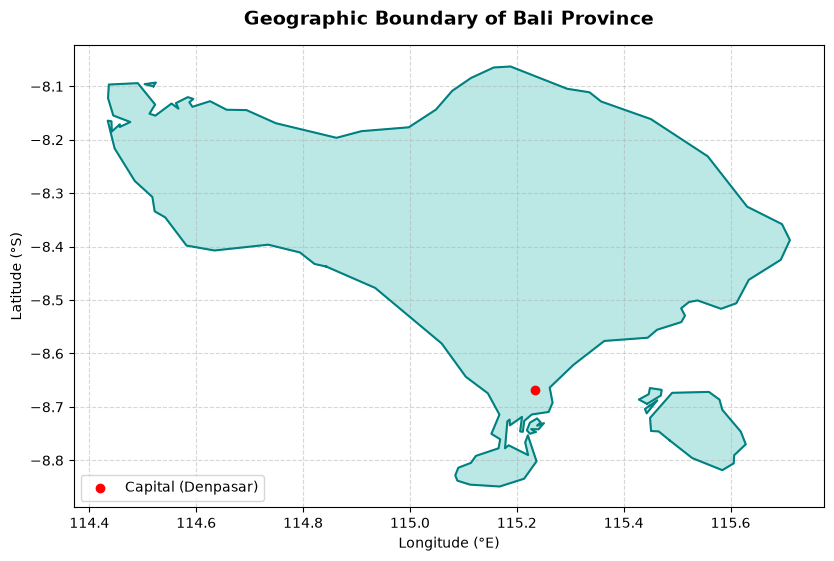

In [26]:
import json
try:
    import matplotlib.pyplot as plt
    
    # 1. Fetch Bali province boundary coordinates
    bali = nus.find_province("51")
    polygon_data = json.loads(bali.boundary)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Recursive helper to plot nested coordinates (handling both Polygon & MultiPolygon)
    def plot_geom(geom, ax):
        if isinstance(geom[0][0], list):
            for part in geom:
                plot_geom(part, ax)
        else:
            # Extract Lat/Lon coordinates
            lats = [coord[0] for coord in geom]
            lons = [coord[1] for coord in geom]
            
            # Plot outline and fill region
            ax.plot(lons, lats, color="#008080", linewidth=1.5)
            ax.fill(lons, lats, color="#20b2aa", alpha=0.3)
            
    plot_geom(polygon_data, ax)
    
    # Set map metadata
    ax.set_title(f"Geographic Boundary of {bali.name} Province", fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Longitude (°E)", fontsize=10)
    ax.set_ylabel("Latitude (°S)", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_aspect("equal")
    
    # Label key cities/centroids
    ax.scatter([bali.longitude], [bali.latitude], color="red", zorder=5, label=f"Capital ({bali.capital})")
    ax.legend(loc="lower left")
    
    plt.show()
except ImportError:
    print("Visualization skipped. Please install matplotlib to view the boundary map:")
    print("  pip install matplotlib")

### 7. Scoped and Fuzzy Search (with `utils.py` helpers)

**Scenario**: In real-world data science applications, user inputs for administrative names are often noisy. They might contain typos (e.g., "Makasar" instead of "Makassar", "Jogjakarta" instead of "Yogyakarta") or you might want to constrain searches to a specific region (e.g., finding villages named "Bakongan" but only within the Aceh province to avoid matching other provinces).

`py-nusantara` provides:
1. **Fuzzy Search**: Typo correction using string similarity algorithms (Levenshtein or Trigram) with custom thresholds.
2. **Scoped Search**: Restricting search scope by specifying a parent region ID (e.g. `province_id` or `regency_id`).
3. **Regional Code Helpers (from `utils.py`)**:
   - `clean_region_code(code)`: Standardizes codes by removing dot separators and extra whitespaces (e.g., `"32.73.01.2001"` -> `"3273012001"`).
   - `format_region_code(code)`: Converts numeric codes to standard Kepmendagri dot-separated format (e.g., `"3273012001"` -> `"32.73.01.2001"`).
   - `validate_region_code(code)`: Validates if a code conforms to standard numeric and length constraints.
4. **String Similarity Utilities (from `utils.py`)**: Built-in string matching functions for custom entity resolution and similarity calculation.

In [27]:
# 1. Fuzzy Search to correct typos (e.g., "Makasar" -> "Kota Makassar", "Jogjakarta" -> "Yogyakarta")
print("--- Fuzzy Search: 'Makasar' ---")
res_fuzzy = nus.search("Makasar", fuzzy=True, threshold=0.7, similarity_method="levenshtein")
for r in res_fuzzy["regencies"]:
    print(f"Matched Regency: {r.name} (ID: {r.id})")

print("\n--- Fuzzy Search: 'Jogjakarta' (Trigram) ---")
res_trigram = nus.search("Jogjakarta", fuzzy=True, threshold=0.3, similarity_method="trigram")
for p in res_trigram["provinces"]:
    print(f"Matched Province: {p.name} (ID: {p.id})")

# 2. Scoped Search: Search for "Bakongan" restricted to Aceh (Province ID '11')
print("\n--- Scoped Search: 'Bakongan' in Aceh ('11') ---")
res_scoped_aceh = nus.search("Bakongan", scope={"province_id": "11"})
for d in res_scoped_aceh["districts"]:
    print(f"District in Aceh: {d.name} (ID: {d.id})")

# Scoped Search: Search for "Bakongan" in West Java (Province ID '32') - should return nothing
print("\n--- Scoped Search: 'Bakongan' in West Java ('32') ---")
res_scoped_jabar = nus.search("Bakongan", scope={"province_id": "32"})
print(f"Districts found in West Java: {len(res_scoped_jabar['districts'])}")

# 3. Regional Code Utility Helpers (clean_region_code, format_region_code, validate_region_code)
print("\n--- Regional Code Utilities ---")
raw_code = "32.73.01.2001"
cleaned = nus.clean_region_code(raw_code)
formatted = nus.format_region_code(cleaned)
is_valid = nus.validate_region_code(raw_code)

print(f"Raw Code: {raw_code}")
print(f"Cleaned: {cleaned}")
print(f"Formatted: {formatted}")
print(f"Is Valid: {is_valid}")

# 4. String Similarity Utilities (from py_nusantara.utils)
print("\n--- String Similarity Utilities ---")
from py_nusantara.utils import string_similarity, levenshtein_distance, trigram_similarity

str1 = "Jogjakarta"
str2 = "Daerah Istimewa Yogyakarta"

lev_dist = levenshtein_distance(str1, str2)
lev_sim = string_similarity(str1, str2, method="levenshtein")
tri_sim = string_similarity(str1, str2, method="trigram")

print(f"Comparing '{str1}' with '{str2}':")
print(f"  Levenshtein Distance: {lev_dist}")
print(f"  Levenshtein Similarity: {lev_sim:.4f}")
print(f"  Trigram Similarity: {tri_sim:.4f}")

--- Fuzzy Search: 'Makasar' ---
Matched Regency: Kota Makassar (ID: 7371)
Matched Regency: Kabupaten Takalar (ID: 7305)
Matched Regency: Kabupaten Mamasa (ID: 7603)

--- Fuzzy Search: 'Jogjakarta' (Trigram) ---
Matched Province: Daerah Khusus Ibukota Jakarta (ID: 31)
Matched Province: Daerah Istimewa Yogyakarta (ID: 34)

--- Scoped Search: 'Bakongan' in Aceh ('11') ---
District in Aceh: Bakongan (ID: 110101)
District in Aceh: Bakongan Timur (ID: 110115)

--- Scoped Search: 'Bakongan' in West Java ('32') ---
Districts found in West Java: 0

--- Regional Code Utilities ---
Raw Code: 32.73.01.2001
Cleaned: 3273012001
Formatted: 32.73.01.2001
Is Valid: True

--- String Similarity Utilities ---
Comparing 'Jogjakarta' with 'Daerah Istimewa Yogyakarta':
  Levenshtein Distance: 18
  Levenshtein Similarity: 0.8000
  Trigram Similarity: 0.3333


### 8. Advanced Spatial Queries & 3D KD-Tree

**Scenario**: You have spatial coordinates and need to query nearest administrative centers (K-Nearest Neighbors), find all administrative regions within a certain radius (e.g., 50km for logistics coverage), check coordinate intersections against viewport bounding boxes, or calculate distances between administrative entities.

`py-nusantara` implements an in-memory **3D KD-Tree** to perform efficient spatial queries without requiring a heavy spatial database.

Let's test these queries (using coordinates near Banda Aceh: lat=5.54, lon=95.32):

In [28]:
# 1. K-Nearest Neighbors (KNN) Search using 3D KD-Tree
print("--- 3 Nearest Provinces to Banda Aceh (lat=5.54, lon=95.32) ---")
nearest_provs = nus.find_knn(5.54, 95.32, k=3, level="provinces")
for idx, p in enumerate(nearest_provs):
    print(f"{idx+1}. {p.name} (Distance: {p.distance_km:.2f} km)")

# 2. Radial Nearby Search
print("\n--- Districts within 50 km of Banda Aceh ---")
nearby_districts = nus.find_nearby(5.54, 95.32, radius_km=50.0, level="districts")
for d in nearby_districts[:5]:
    print(f"- {d.name} (Distance: {d.distance_km:.2f} km)")

# 3. Bounding Box (BBox) Query
# Define a bounding box around northern Sumatra
print("\n--- Provinces in Bounding Box ---")
bbox_regions = nus.find_in_bbox(min_lat=2.0, min_lon=95.0, max_lat=6.0, max_lon=98.0, level="provinces")
for r in bbox_regions:
    print(f"- {r.name} (Centroid: {r.latitude}, {r.longitude})")

# 4. Great-Circle Distance between two regions (Aceh Selatan regency to Banda Aceh)
r1 = nus.find_regency("1101")
r2 = nus.find_regency("1171")
if r1 and r2:
    dist = r1.distance_to(r2)
    print(f"\nDistance between {r1.name} and {r2.name}: {dist:.2f} km")

--- 3 Nearest Provinces to Banda Aceh (lat=5.54, lon=95.32) ---
1. Aceh (Distance: 4.10 km)
2. Sumatera Utara (Distance: 430.70 km)
3. Riau (Distance: 879.92 km)

--- Districts within 50 km of Banda Aceh ---
- Baiturrahman (Distance: 0.54 km)
- Banda Raya (Distance: 1.54 km)
- Lueng Bata (Distance: 1.65 km)
- Jaya Baru (Distance: 2.61 km)
- Meuraxa (Distance: 3.11 km)

--- Provinces in Bounding Box ---
- Aceh (Centroid: 5.570546962920454, 95.34080851187178)

Distance between Kabupaten Aceh Selatan and Kota Banda Aceh: 327.85 km


### 9. Historical Regional ID Mapping & Legacy NIK Parsing

**Scenario**: Indonesia's administrative divisions change over time (e.g., provinces split into new ones, such as Papua split into Papua Selatan, Papua Tengah, etc.). Older database records or user NIKs (National ID numbers) might use legacy regional codes. You need to map these legacy codes transparently to active ones and resolve NIK positions correctly.

`py-nusantara` maps historical code splits transparently and handles legacy NIK parsing automatically.

Let's see this in action:

In [29]:
# 1. Historical split resolution
# '9101' is Merauke in old Papua province. It split and became '9301' in Papua Selatan.
legacy_id = "9101"
active_id = nus.resolve_legacy_id(legacy_id)
print(f"Legacy ID: {legacy_id} -> Resolved Active ID: {active_id}")

# Transparent lookup fallback: lookup using legacy ID
merauke = nus.find_regency("9101")
print(f"Lookup by legacy '9101' -> Name: {merauke.name}, Current ID: {merauke.id}")

# 2. Parsing a legacy NIK
# This NIK uses legacy Merauke prefix (starts with '910101')
legacy_nik = "9101010402020001"
nik_info = nus.parse_nik(legacy_nik)

print(f"\nParsed Legacy NIK: {legacy_nik}")
print(f"Gender: {nik_info.gender}")
print(f"Birth Date: {nik_info.birth_date}")
print(f"Resolved Province: {nik_info.province.name} (Current ID: {nik_info.province.id})")
print(f"Resolved Regency: {nik_info.regency.name} (Current ID: {nik_info.regency.id})")
print(f"Resolved District: {nik_info.district.name} (Current ID: {nik_info.district.id})")

# Retrieve all villages under the NIK's resolved district
villages = nik_info.district.villages
print(f"Villages in District (Total: {len(villages)}):")
for v in villages[:5]:
    print(f"  - {v.name} (Postal Code: {v.postal_code})")

Legacy ID: 9101 -> Resolved Active ID: 9301
Lookup by legacy '9101' -> Name: Kabupaten Merauke, Current ID: 9301

Parsed Legacy NIK: 9101010402020001
Gender: male
Birth Date: 2002-02-04
Resolved Province: Papua Selatan (Current ID: 93)
Resolved Regency: Kabupaten Merauke (Current ID: 9301)
Resolved District: Merauke (Current ID: 930101)
Villages in District (Total: 16):
  - Samkai (Postal Code: 99615)
  - Karang Indah (Postal Code: 99614)
  - Mandala (Postal Code: 99617)
  - Maro (Postal Code: 99613)
  - Kelapa Lima (Postal Code: 99612)


### 10. GeoJSON Export for GIS Mapping

**Scenario**: You want to export boundary and metadata records to standard GeoJSON format to load them into map renderers (Leaflet, Mapbox, Folium) or geographic data analysis tools (GeoPandas, Shapely).

The `.to_geojson()` method on any region record generates standard GeoJSON features (representing either a point or exact boundary polygon/multipolygon depending on boundary configurations).

Let's export Bali province to GeoJSON:

In [30]:
# Fetch Bali province (with boundary enabled in Config)
bali = nus.find_province("51")
geojson = bali.to_geojson()

# Display the GeoJSON Feature structure (truncated for readability)
print("GeoJSON Type:", geojson["type"])
print("Geometry Type:", geojson["geometry"]["type"])
print("Properties:", list(geojson["properties"].keys()))
print("\nSample coordinates subset:")
if geojson["geometry"]["type"] == "Polygon":
    print(geojson["geometry"]["coordinates"][0][:3])
else:
    print(geojson["geometry"]["coordinates"])

GeoJSON Type: Feature
Geometry Type: Polygon
Properties: ['id', 'name', 'capital', 'latitude', 'longitude', 'elevation', 'timezone', 'area', 'population']

Sample coordinates subset:
[[114.519701, -8.100002], [114.503341, -8.095996], [114.524537, -8.092949]]
